<a href="https://colab.research.google.com/github/LilaNguyen/Skinterest-Tech-1B/blob/main/notebooks/skinterest1b_milestone2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Community Segmentation and Categorization Community
Segment customers into distinct skincare communities based on skin concerns, product preferences, and review behavior

## Import Packages

In [40]:
import numpy as np
import pandas as pd
import os
import gc

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import MiniBatchKMeans

from sklearn.metrics import (
    silhouette_score, calinski_harabasz_score, davies_bouldin_score,
    adjusted_rand_score, normalized_mutual_info_score,
    homogeneity_score, completeness_score, v_measure_score,
    confusion_matrix
)

from scipy.sparse import hstack, csr_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

## Load in the Data

In [41]:
root = kagglehub.dataset_download("melissamonfared/sephora-skincare-reviews")

product_df = pd.read_csv(os.path.join(root, 'product_info.csv'))

review_files = [f for f in os.listdir(root) if f.startswith("reviews_")]
chunks = []

for file in sorted(review_files):
    for chunk in pd.read_csv(os.path.join(root, file), chunksize=50000):
        chunks.append(chunk)

reviews_df = pd.concat(chunks, ignore_index=True)
gc.collect()

merged_df = reviews_df.merge(product_df, on="product_id")

Using Colab cache for faster access to the 'sephora-skincare-reviews' dataset.


## Data Preprocessing

### Inspect the data

In [42]:
# get dimensions
merged_df.shape

(285412, 45)

In [43]:
# get data types
merged_df.dtypes

,0
Unnamed: 0.1,int64
Unnamed: 0,int64
rating_x,int64
is_recommended,float64
helpfulness,float64
total_feedback_count,int64
total_neg_feedback_count,int64
total_pos_feedback_count,int64
submission_time,object
review_text,object


In [44]:
# display summary stats
merged_df.describe(include='all')

,Unnamed: 0.1,Unnamed: 0,rating_x,is_recommended,helpfulness,total_feedback_count,total_neg_feedback_count,total_pos_feedback_count,submission_time,review_text,...,online_only,out_of_stock,sephora_exclusive,highlights,primary_category,secondary_category,tertiary_category,child_count,child_max_price,child_min_price
count,285412.000000,285412.000000,285412.000000,228180.000000,131090.000000,285412.000000,285412.000000,285412.000000,285412,285067,...,285412.000000,285412.000000,285412.000000,263408,285412,285412,231308,285412.000000,129094.000000,129094.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5302,244922,...,NaN,NaN,NaN,381,1,13,23,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020-10-21,I love ALL of the Dr. Jart masks so much!!! Th...,...,NaN,NaN,NaN,"['allure 2019 Best of Beauty Award Winner', 'C...",Skincare,Cleansers,Face Wash & Cleansers,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1284,11,...,NaN,NaN,NaN,16138,285412,90702,87926,NaN,NaN,NaN
mean,180616.184242,180616.184242,4.330526,0.843864,0.775019,3.199368,0.685928,2.513440,NaN,NaN,...,0.155470,0.031316,0.300961,NaN,NaN,NaN,NaN,0.827306,41.222140,21.087780
std,168373.481176,168373.481176,1.122987,0.362985,0.320146,20.588738,4.621723,18.311465,NaN,NaN,...,0.362353,0.174171,0.458677,NaN,NaN,NaN,NaN,1.117528,37.336377,13.147197
min,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,...,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000,3.500000,3.500000
25%,41419.000000,41419.000000,4.000000,1.000000,0.666667,0.000000,0.000000,0.000000,NaN,NaN,...,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000,20.000000,15.000000
50%,115587.500000,115587.500000,5.000000,1.000000,1.000000,0.000000,0.000000,0.000000,NaN,NaN,...,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000,26.000000,18.000000
75%,325059.250000,325059.250000,5.000000,1.000000,1.000000,3.000000,0.000000,2.000000,NaN,NaN,...,0.000000,0.000000,1.000000,NaN,NaN,NaN,NaN,1.000000,51.000000,24.000000


In [45]:
merged_df.head(10)

,Unnamed: 0.1,Unnamed: 0,rating_x,is_recommended,helpfulness,total_feedback_count,total_neg_feedback_count,total_pos_feedback_count,submission_time,review_text,...,online_only,out_of_stock,sephora_exclusive,highlights,primary_category,secondary_category,tertiary_category,child_count,child_max_price,child_min_price
0,0,0,5,1.0,1.00,2,0,2,2023-02-01,I use this with the Nudestix “Citrus Clean Bal...,...,1,0,0,['Clean at Sephora'],Skincare,Cleansers,NaN,0,NaN,NaN
1,1,1,1,0.0,NaN,0,0,0,2023-03-21,I bought this lip mask after reading the revie...,...,0,0,1,"['allure 2019 Best of Beauty Award Winner', 'C...",Skincare,Lip Balms & Treatments,NaN,3,24.0,24.0
2,2,2,5,1.0,NaN,0,0,0,2023-03-21,My review title says it all! I get so excited ...,...,0,0,1,"['allure 2019 Best of Beauty Award Winner', 'C...",Skincare,Lip Balms & Treatments,NaN,3,24.0,24.0
3,3,3,5,1.0,NaN,0,0,0,2023-03-20,I’ve always loved this formula for a long time...,...,0,0,1,"['allure 2019 Best of Beauty Award Winner', 'C...",Skincare,Lip Balms & Treatments,NaN,3,24.0,24.0
4,4,4,5,1.0,NaN,0,0,0,2023-03-20,"If you have dry cracked lips, this is a must h...",...,0,0,1,"['allure 2019 Best of Beauty Award Winner', 'C...",Skincare,Lip Balms & Treatments,NaN,3,24.0,24.0
5,5,5,4,1.0,1.00,1,0,1,2023-03-19,The scent isn’t my favourite but it works grea...,...,0,0,1,"['allure 2019 Best of Beauty Award Winner', 'C...",Skincare,Lip Balms & Treatments,NaN,3,24.0,24.0
6,6,6,2,0.0,0.25,8,6,2,2023-03-19,I’ll give this 2 stars for nice packaging and ...,...,0,0,1,"['allure 2019 Best of Beauty Award Winner', 'C...",Skincare,Lip Balms & Treatments,NaN,3,24.0,24.0
7,7,7,5,1.0,NaN,0,0,0,2023-03-19,I use this at night or while I’m putting makeu...,...,0,0,1,"['allure 2019 Best of Beauty Award Winner', 'C...",Skincare,Lip Balms & Treatments,NaN,3,24.0,24.0
8,8,8,5,1.0,1.00,1,0,1,2023-03-18,I love this stuff. I first had the sample size...,...,0,0,1,"['allure 2019 Best of Beauty Award Winner', 'C...",Skincare,Lip Balms & Treatments,NaN,3,24.0,24.0
9,9,9,5,1.0,1.00,2,0,2,2023-03-18,I purchased the Sweet Candy scent at my local ...,...,0,0,1,"['allure 2019 Best of Beauty Award Winner', 'C...",Skincare,Lip Balms & Treatments,NaN,3,24.0,24.0


### Addressing missing values

In [46]:
merged_df = merged_df.drop(columns=['Unnamed: 0.1', 'Unnamed: 0'], errors='ignore')

# Drop columns with >50% missing values
missing_pct = merged_df.isnull().mean() * 100
merged_df = merged_df.drop(columns=missing_pct[missing_pct > 50].index)

In [47]:
# keep only relevant features
relevant_cols = [
    'skin_type','skin_tone','primary_category','secondary_category','brand_name_x',
    'price_usd_x','ingredients','loves_count','limited_edition','sephora_exclusive',
    'new','rating_x','is_recommended','total_feedback_count',
    'total_pos_feedback_count','total_neg_feedback_count','review_text'
]
skin_df = merged_df[relevant_cols].copy()

In [48]:
# check missingness in relevant df
skin_df.isnull().sum().sort_values(ascending=False)

,0
is_recommended,57232
skin_tone,55226
skin_type,36874
ingredients,3731
review_text,345
brand_name_x,0
price_usd_x,0
secondary_category,0
primary_category,0
limited_edition,0


In [49]:
# fill missing values
skin_df['skin_type'] = skin_df['skin_type'].fillna('Unknown')
skin_df['skin_tone'] = skin_df['skin_tone'].fillna('Unknown')
skin_df['review_text'] = skin_df['review_text'].fillna('')
skin_df['ingredients'] = skin_df['ingredients'].fillna('')
skin_df['is_recommended'] = skin_df['is_recommended'].fillna(
    skin_df['is_recommended'].mode()[0]
)

### Normalize numerical features

In [50]:
# selecting numerical columns
num_cols = skin_df.select_dtypes(include=np.number).columns
minmax = MinMaxScaler()

# apply normalization
skin_df[num_cols] = minmax.fit_transform(skin_df[num_cols])

# convert to numeric sparse matrix
numeric_sparse = csr_matrix(skin_df[num_cols].values)

### Standardize and scale parameters

In [12]:
# Apply standardization
# skin_df[numerical_cols] = scaler.fit_transform(skin_df[numerical_cols])

# display(skin_df.head())

### Feature engineer categorical variables

In [51]:
# label categorical cols
cat_cols = [
    'skin_type','skin_tone',
    'primary_category','secondary_category',
    'brand_name_x'
]

for col in cat_cols:
    le = LabelEncoder()
    skin_df[col] = le.fit_transform(skin_df[col].astype(str))

Feature Engineering: TF-IDF

In [52]:
review_tfidf = TfidfVectorizer(max_features=1000).fit_transform(skin_df['review_text'])

ingredient_tfidf = TfidfVectorizer(max_features=1000).fit_transform(skin_df['ingredients'])

X = hstack([numeric_sparse, review_tfidf, ingredient_tfidf])

## Making the Model

In [53]:
K_range = range(2, 15)
inertias = []

for k in K_range:
    mbk = MiniBatchKMeans(
        n_clusters=k, random_state=42, batch_size=4096
    )
    mbk.fit(X)
    inertias.append(mbk.inertia_)

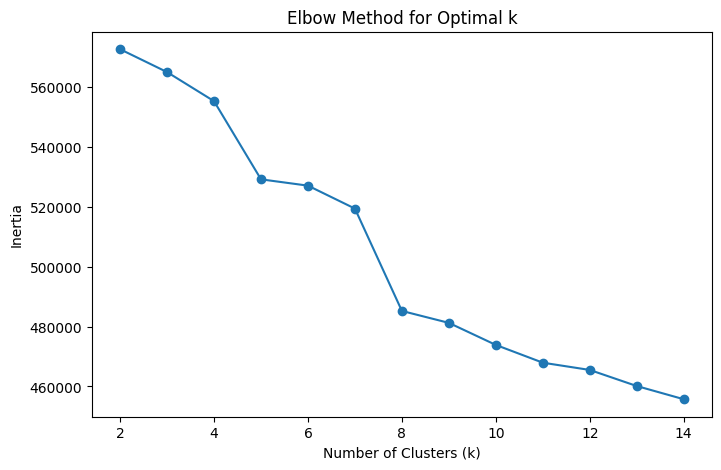

In [54]:
plt.figure(figsize=(8,5))
plt.plot(K_range, inertias, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.show()

In [55]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

k = 8

scaler = StandardScaler(with_mean=False)
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=k, random_state=42)
labels = kmeans.fit_predict(X_scaled)

skin_df['cluster'] = labels

## Testing the Model

In [56]:
# cluster profiling
numeric_df = skin_df.select_dtypes(include='number')

cluster_means = numeric_df.groupby(skin_df['cluster']).mean()

# global stats
global_mean = numeric_df.mean()
global_std = numeric_df.std()

# z-score deviation for each cluster
cluster_zscores = (cluster_means - global_mean) / global_std

In [57]:
from collections import Counter
import re

# Keep original brand names and ingredients for plotting
skin_df['brand_name_orig'] = merged_df['brand_name_x']
skin_df['ingredients_orig'] = merged_df['ingredients']

# Normalization dict
ingredient_mapping = {
    'eau': 'water',
    'aqua': 'water',
    'h2o': 'water',
    # add other synonyms if needed
}

def normalize_ingredient(x):
    x = x.lower().strip()
    return ingredient_mapping.get(x, x)

top_ing_counts = {}
top_brands = {}

for c in range(k):
    cluster_rows = skin_df[skin_df['cluster'] == c]

    all_ings = []
    for entry in cluster_rows['ingredients_orig']:
        if pd.isna(entry):
            continue
        parts = [p.strip() for p in re.split(r'[,/]', entry) if p.strip()]
        all_ings.extend(normalize_ingredient(p) for p in parts)

    top_ing_counts[c] = Counter(all_ings).most_common(5)
    top_brands[c] = cluster_rows['brand_name_orig'].value_counts().head(5)

In [58]:
# Define descriptive labels for each cluster
cluster_labels = {
    0: "High-priced specialty products",
    1: "Brand-focused new arrivals",
    2: "Popular brands with high engagement",
    3: "Highly loved exclusive products",
    4: "Average-priced general products",
    5: "Category-focused products",
    6: "Brand & skin-tone specific products",
    7: "Premium exclusives with popular brands"
}

summary = []

for c in range(k):
    strengths = cluster_zscores.loc[c].sort_values(ascending=False).head(3)
    weaknesses = cluster_zscores.loc[c].sort_values().head(3)

    summary.append({
        "Cluster": c,
        "Label": cluster_labels[c],
        "Key Strengths": ", ".join(f"{f} ({v:.2f})" for f, v in strengths.items()),
        "Key Weaknesses": ", ".join(f"{f} ({v:.2f})" for f, v in weaknesses.items()),
        "Top Ingredients": [i for i, _ in top_ing_counts[c]],
        "Top Brands": top_brands[c].index.tolist()
    })

cluster_summary_df = pd.DataFrame(summary)
cluster_summary_df

,Cluster,Label,Key Strengths,Key Weaknesses,Top Ingredients,Top Brands
0,0,High-priced specialty products,"price_usd_x (1.51), secondary_category (1.35),...","cluster (-2.11), brand_name_x (-1.14), sephora...","[butylene glycol, caffeine, sodium hyaluronate...","[Estée Lauder, CLINIQUE]"
1,1,Brand-focused new arrivals,"brand_name_x (0.34), new (0.31), loves_count (...","cluster (-1.45), secondary_category (-0.43), p...","[water, glycerin, phenoxyethanol, sodium chlor...","[First Aid Beauty, Youth To The People, Tatcha..."
2,2,Popular brands with high engagement,"brand_name_x (1.48), loves_count (0.57), is_re...","secondary_category (-1.17), cluster (-0.80), s...","[['aqua (water), coco-glucoside, butylene glyc...",[fresh]
3,3,Highly loved exclusive products,"loves_count (3.32), sephora_exclusive (1.52), ...","price_usd_x (-0.60), new (-0.19), cluster (-0.14)","[water, ethylene, styrene copolymer, hydrogena...","[LANEIGE, belif]"
4,4,Average-priced general products,"cluster (0.51), price_usd_x (0.05), is_recomme...","loves_count (-0.34), brand_name_x (-0.13), lim...","[water, glycerin, ['water, phenoxyethanol, but...","[CLINIQUE, Origins, Peter Thomas Roth, Murad, ..."
5,5,Category-focused products,"secondary_category (1.46), cluster (1.17), bra...","sephora_exclusive (-0.66), skin_tone (-0.60), ...","[water, ['water, peg-32, cellulose, butylene g...",[Peter Thomas Roth]
6,6,Brand & skin-tone specific products,"cluster (1.82), brand_name_x (0.64), skin_tone...","sephora_exclusive (-0.57), is_recommended (-0....","[water, ['water, glycerin, ceramide eop, ceram...","[Summer Fridays, Drunk Elephant, IT Cosmetics]"
7,7,Premium exclusives with popular brands,"cluster (2.48), sephora_exclusive (1.52), bran...","loves_count (-0.32), new (-0.19), limited_edit...","[water, ['aqua, dimethicone, diglycerin, sacch...",[Tatcha]


Top strengths:
* Cluster 0: high-priced products in specific cats
* Cluster 3: highly loved exclusive products dominate

Top weaknesses:
* Cluster 2: not associated with secondary cats
* Cluster 5: rarely exclusive or skin-tone specific products

All others:
* Cluster 1: brand-driven, new products dominate
* Cluster 4: not distinctive
* Cluster 6: brand and skin tone specific
* Cluster 7: brand and exclusivity

## Model Validation

In [59]:
# Clustering metrics:

# sample for silhouette
sample_idx = np.random.choice(X_scaled.shape[0], 3000, replace=False)
X_sample = X_scaled[sample_idx]
labels_sample = labels[sample_idx]

sil = silhouette_score(X_sample, labels_sample)
ch = calinski_harabasz_score(X_sample.toarray(), labels_sample)
db = davies_bouldin_score(X_sample.toarray(), labels_sample)

print(f"Silhouette Score: {sil:.3f}")
print(f"Calinski-Harabasz Index: {ch:.1f}")
print(f"Davies-Bouldin Index: {db:.3f}")

Silhouette Score: -0.018
Calinski-Harabasz Index: 37.1
Davies-Bouldin Index: 4.038


## Visualizations

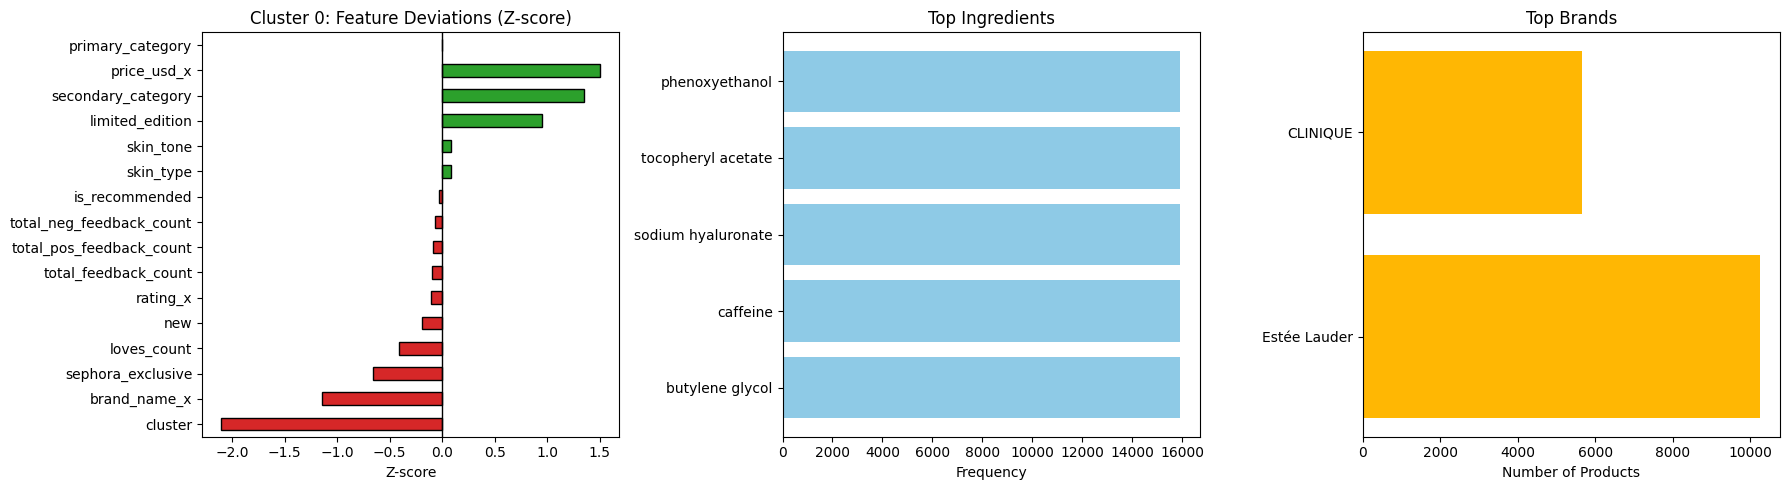

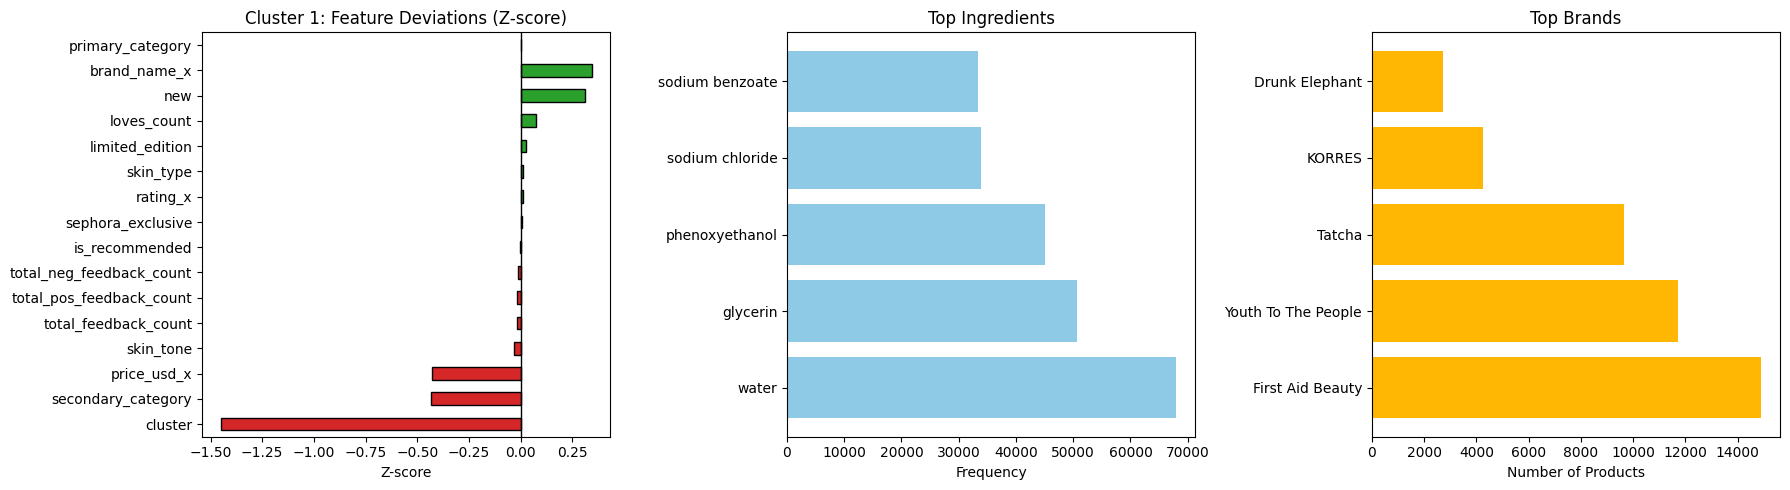

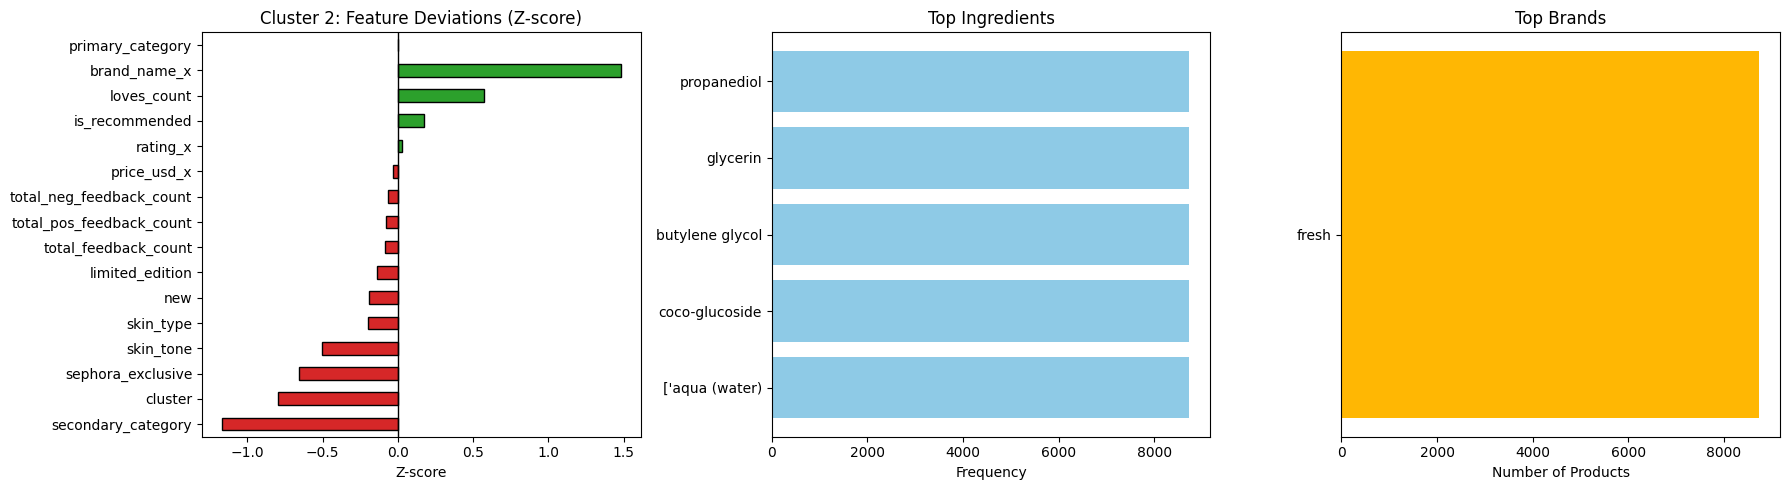

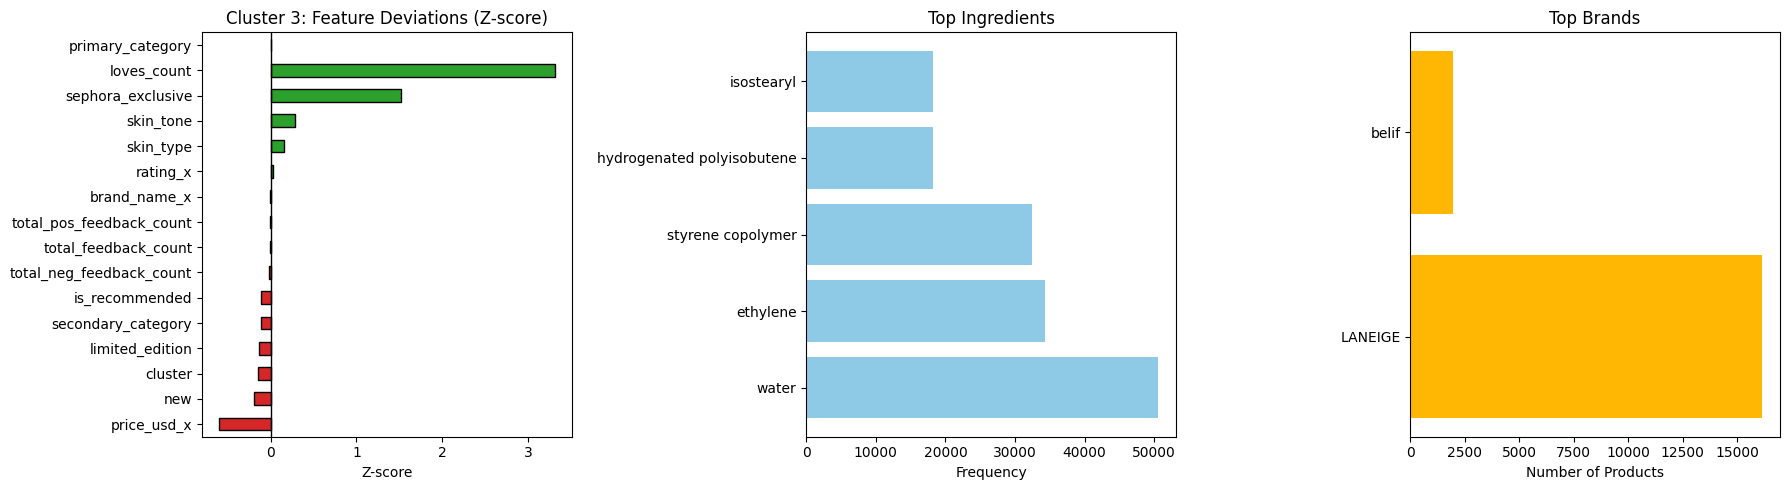

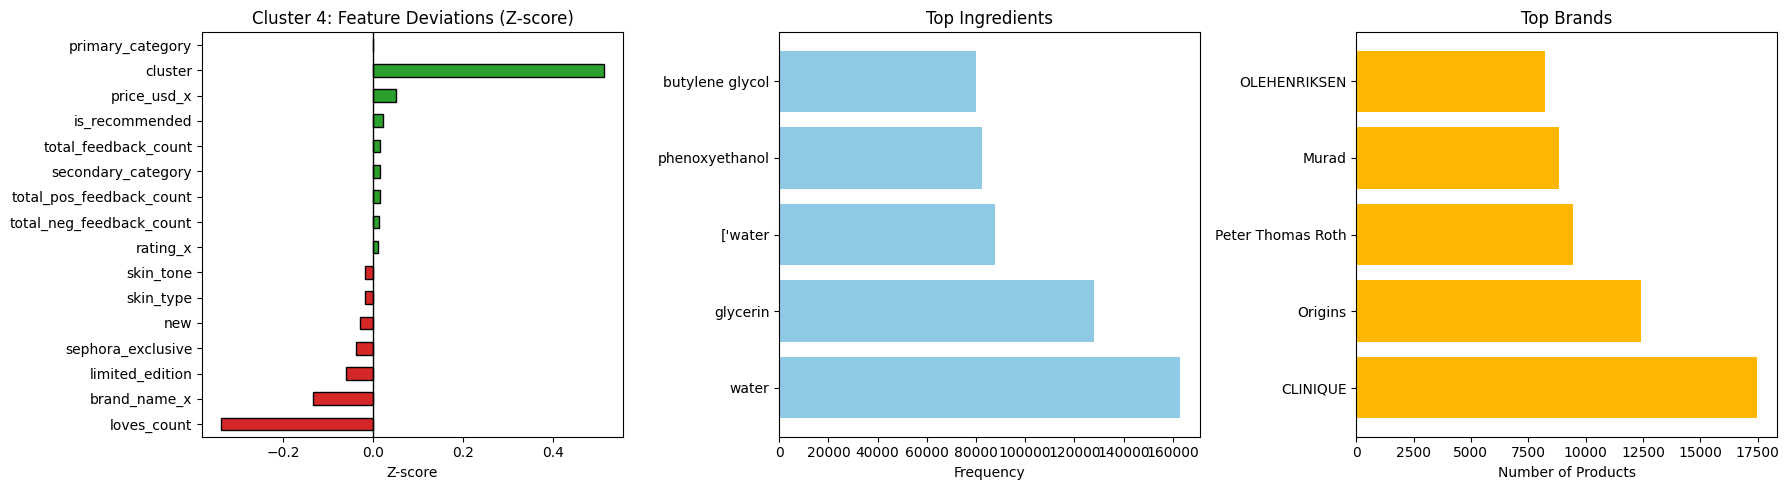

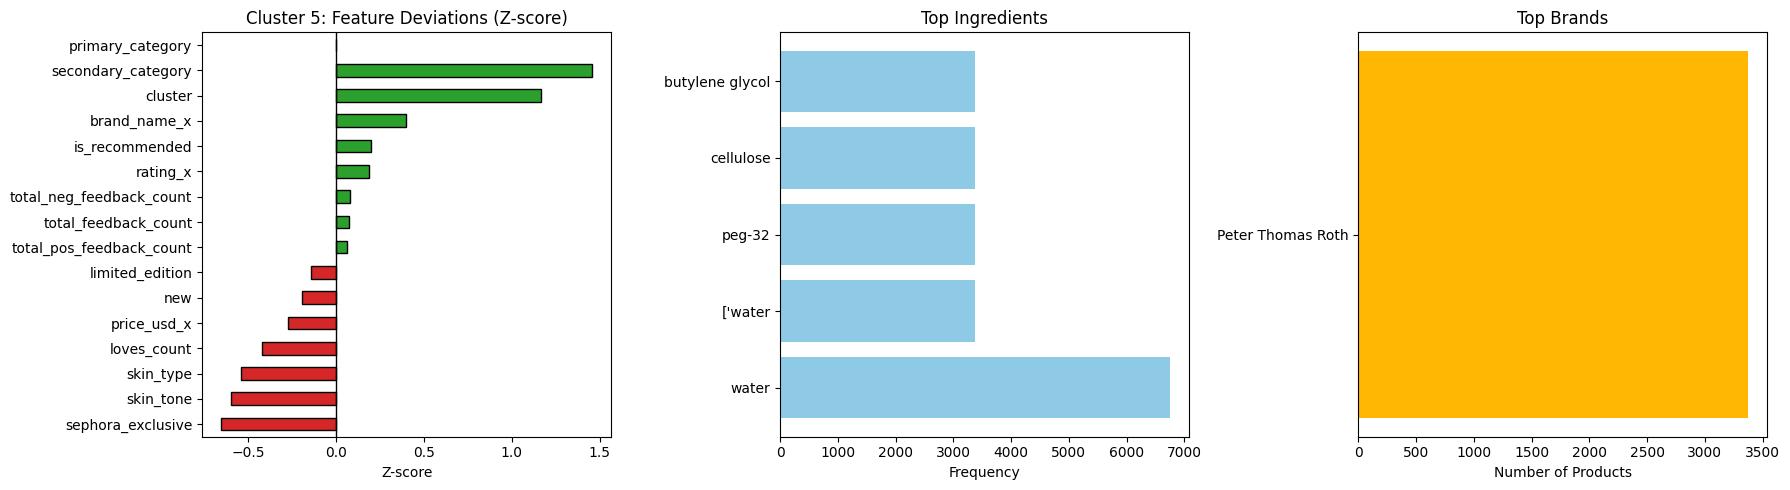

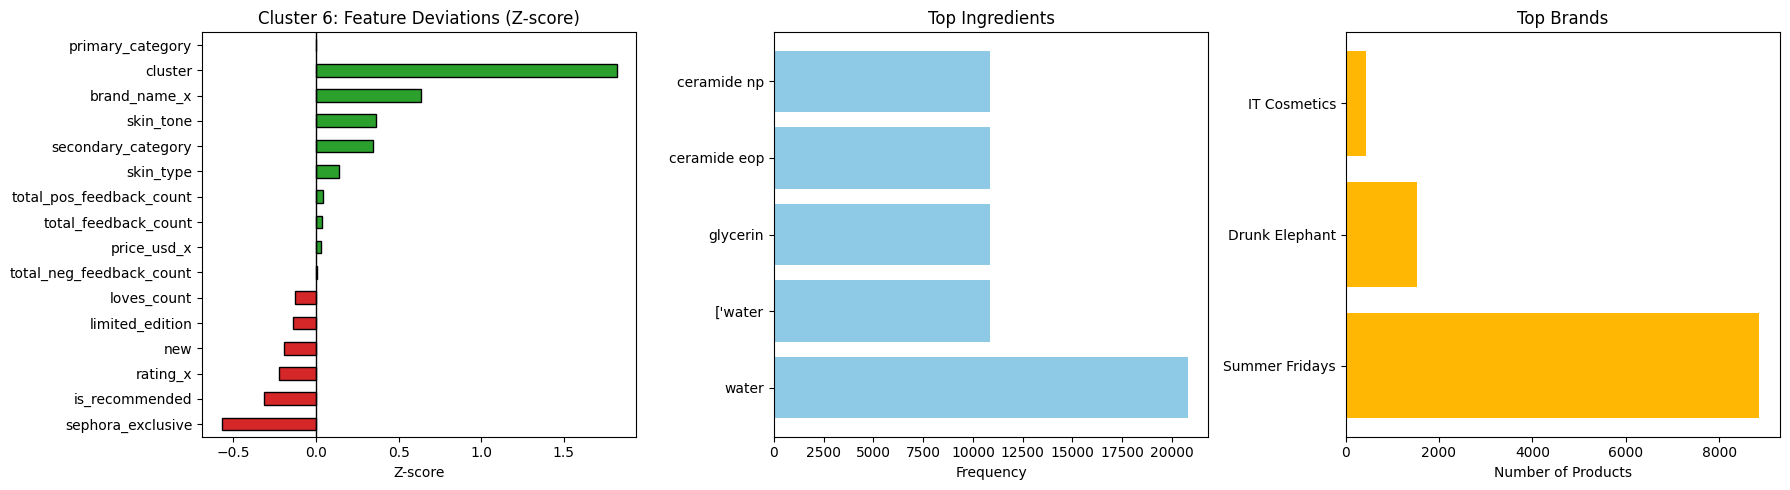

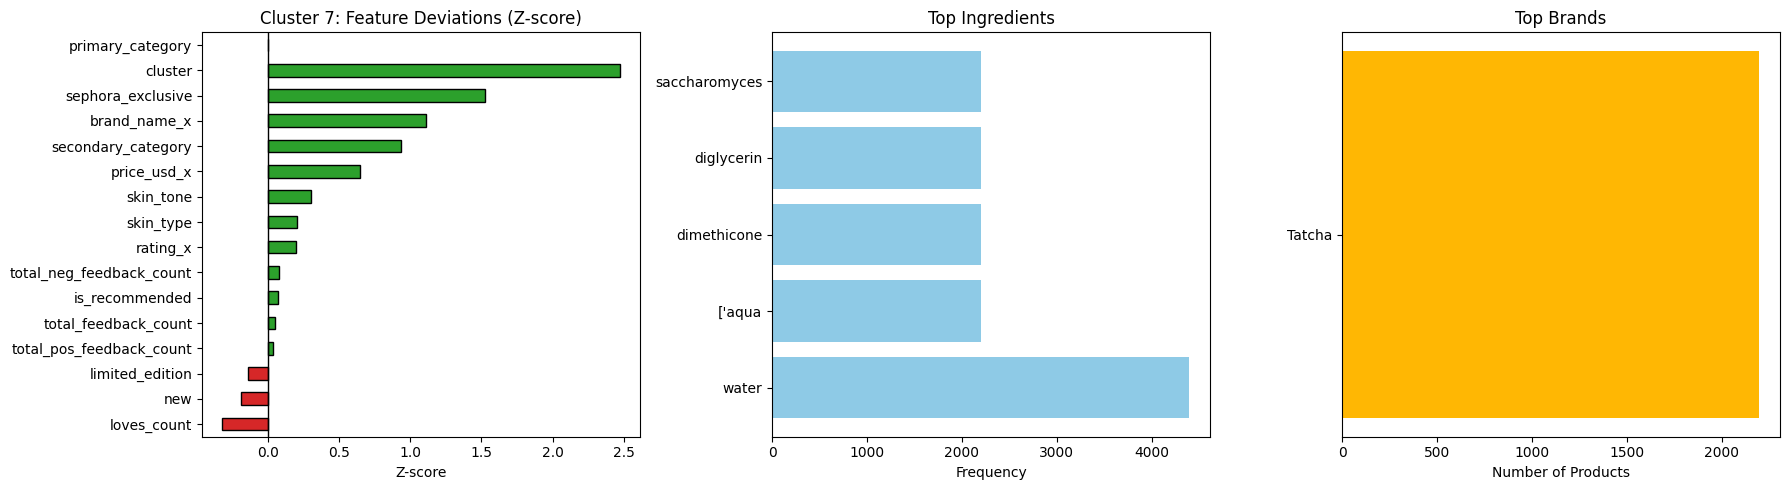

In [60]:
clusters_to_plot = range(k)

for c in clusters_to_plot:
    fig, axs = plt.subplots(1, 3, figsize=(18, 5))

    # stregnths/weaknesses
    scores = cluster_zscores.loc[c].sort_values()
    colors = ['#d62728' if v < 0 else '#2ca02c' for v in scores]

    scores.plot(
        kind='barh',
        ax=axs[0],
        color=colors,
        edgecolor='black'
    )
    axs[0].axvline(0, color='black', linewidth=1)
    axs[0].set_title(f'Cluster {c}: Feature Deviations (Z-score)')
    axs[0].set_xlabel('Z-score')

    # top ingredients
    ing, cnt = zip(*top_ing_counts[c]) if top_ing_counts[c] else ([], [])
    axs[1].barh(ing, cnt, color='#8ecae6')
    axs[1].set_title('Top Ingredients')
    axs[1].set_xlabel('Frequency')

    # top brands
    br = top_brands[c]
    axs[2].barh(br.index, br.values, color='#ffb703')
    axs[2].set_title('Top Brands')
    axs[2].set_xlabel('Number of Products')

    plt.tight_layout()
    plt.show()

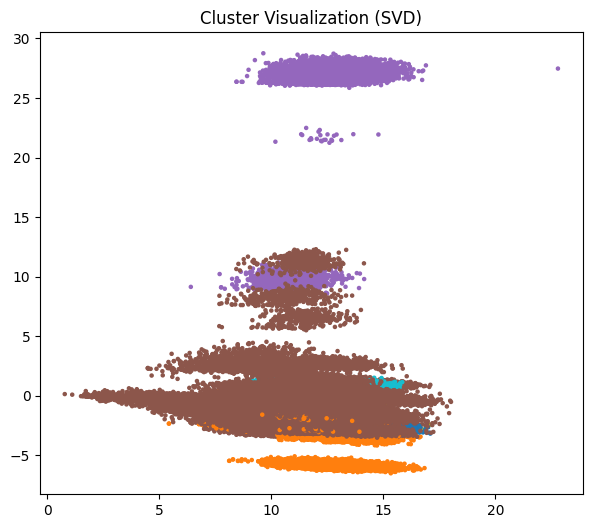

In [61]:
from sklearn.decomposition import TruncatedSVD

# Truncated SVD (for sparse or high-dimensional data)
svd = TruncatedSVD(n_components=2)
coords_svd = svd.fit_transform(X_scaled)

plt.figure(figsize=(7,6))
plt.scatter(coords_svd[:,0], coords_svd[:,1], c=labels, s=5, cmap='tab10')
plt.title("Cluster Visualization (SVD)")
plt.show()

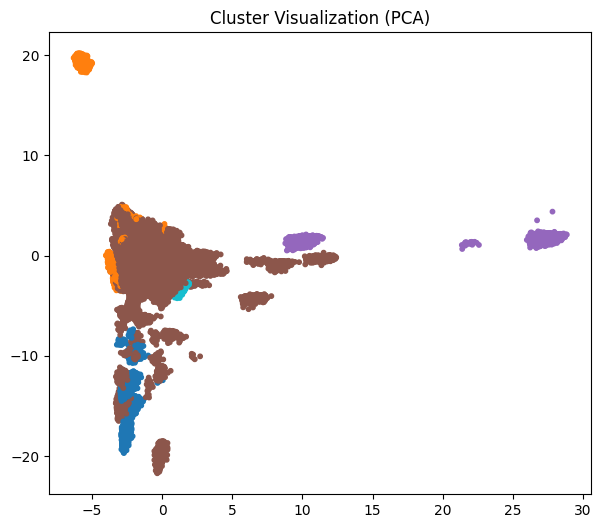

In [62]:
# PCA for clusters
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
coords_pca = pca.fit_transform(X_scaled.toarray())

plt.figure(figsize=(7,6))
plt.scatter(coords_pca[:,0], coords_pca[:,1], c=labels, cmap='tab10', s=10)
plt.title("Cluster Visualization (PCA)")
plt.show()